In [1]:
import pandas as pd
sales2df = pd.read_csv("sales_clean.csv")

In [2]:
sales2df.shape

(289, 6)

In [3]:
sales2df.head()

,order_id,date,product,price,qty,zip
0,1254,2026-04-06,mug,11.36,4,60614
1,1057,2026-05-30,charger,14.79,3,30303
2,1150,2026-05-06,mug,5.50,1,10001
3,1066,2026-05-30,notebook,37.53,1,98101
4,1114,2026-04-06,webcam,45.59,4,90405


In [4]:
sales2df.info()

<class 'pandas.DataFrame'>
RangeIndex: 289 entries, 0 to 288
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   order_id  289 non-null    int64  
 1   date      289 non-null    str    
 2   product   289 non-null    str    
 3   price     289 non-null    float64
 4   qty       289 non-null    int64  
 5   zip       289 non-null    int64  
dtypes: float64(1), int64(3), str(2)
memory usage: 13.7 KB


In [5]:
sales2df.describe()

,order_id,price,qty,zip
count,289.000000,289.000000,289.000000,289.000000
mean,1145.633218,55.723633,2.979239,45554.557093
std,84.420433,72.105147,1.409141,39227.782569
min,1000.000000,2.930000,1.000000,2116.000000
25%,1073.000000,10.970000,2.000000,2134.000000
50%,1146.000000,37.530000,3.000000,30303.000000
75%,1218.000000,56.380000,4.000000,90210.000000
max,1291.000000,479.290000,5.000000,98101.000000


In [6]:
print(sales2df["price"].mean())
print(sales2df["price"].median())
print(sales2df["price"].std())

55.723633217993076
37.53
72.10514653300109


In [7]:
print(sales2df["qty"].mean())
print(sales2df["qty"].median())
print(sales2df["qty"].std())

2.9792387543252596
3.0
1.4091410806443596


For the "price" column, the mean and median do not agree. The mean is substantially higher, which implies a dataset that is skewed right. It would be best to report the median because that would compensate for the few scattered high values that are skewing the mean higher. The median is less sensitive to outliers than the mean is. The standard deviation is another indicator that the values for "price" are quite varied, as the standard deviation is roughly twice the median and is close to 1.5x the mean. This indicates that the average distance from the mean is very high, which would be true if there are outliers.

<Axes: ylabel='Frequency'>

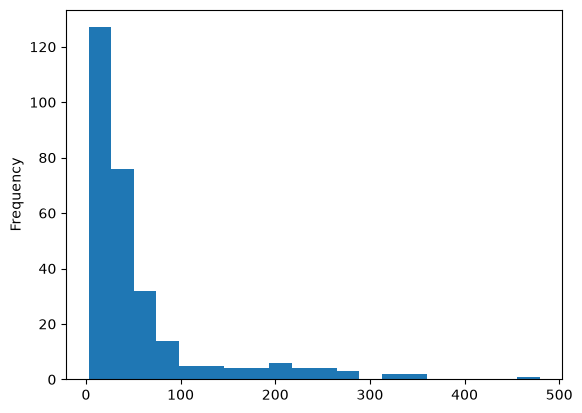

In [8]:
sales2df["price"].plot(kind="hist", bins=20)

The histogram confirms our suspicion that the shape of the data is right-skewed.

In [9]:
sales2df["revenue"] = sales2df["price"] * sales2df["qty"]

In [10]:
sales2df.shape

(289, 7)

In [11]:
sales2df.head()

,order_id,date,product,price,qty,zip,revenue
0,1254,2026-04-06,mug,11.36,4,60614,45.44
1,1057,2026-05-30,charger,14.79,3,30303,44.37
2,1150,2026-05-06,mug,5.50,1,10001,5.50
3,1066,2026-05-30,notebook,37.53,1,98101,37.53
4,1114,2026-04-06,webcam,45.59,4,90405,182.36


In [12]:
sales2df.corr(numeric_only=True)

,order_id,price,qty,zip,revenue
order_id,1.000000,-0.004081,0.026030,-0.016886,0.003909
price,-0.004081,1.000000,-0.040190,0.023194,0.821184
qty,0.026030,-0.040190,1.000000,0.080835,0.313952
zip,-0.016886,0.023194,0.080835,1.000000,0.044752
revenue,0.003909,0.821184,0.313952,0.044752,1.000000


<Axes: xlabel='qty', ylabel='revenue'>

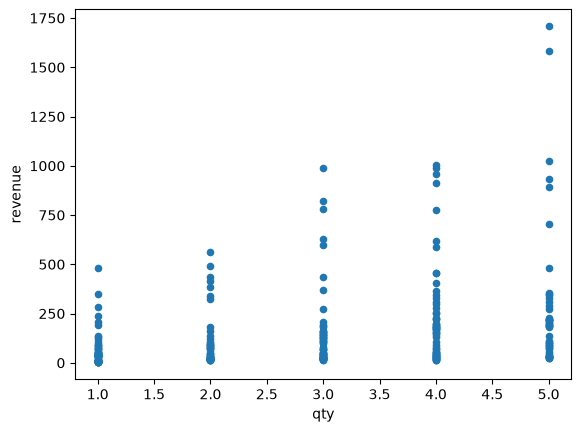

In [13]:
sales2df.plot.scatter(x="qty", y="revenue")

<Axes: xlabel='price', ylabel='revenue'>

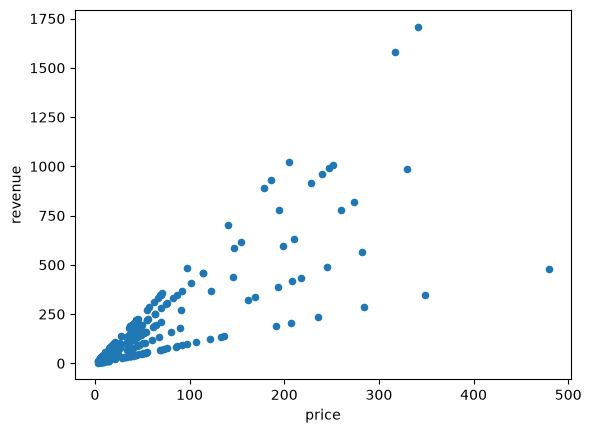

In [14]:
sales2df.plot.scatter(x="price", y="revenue")

The correlation between "qty" and "revenue" is notable (r ~= 0.314) but not as strong as the correlation between "price" and "revenue" (r ~= 0.821). When we visualize the relationships between these variables, both relationships do trend upward, but it is far from a direct linear relationship in either case. Caution is necessary, as even the maximum value of "qty" (5) does not necessarily yield high revenue. This may be the result of a confounder; for example, a heavily-discounted sale may motivate clients to buy a high volume of a low-priced item, such that the total revenue from that client is not high even if they are buying five of a given item. 

[2, 4, 4, 6, 9]
<p>
mean = (2 + 4 + 4 + 6 + 9) / 5<br>
mean = (6 + 10 + 9) / 5<br>
mean = 25 / 5 = 5
</p><p>
median: 2, 4, 4, 6, 9 -> 4, 4, 6 -> 4<br>
median = 4</p>

In [15]:
data = [2, 4, 4, 6, 9]
testdf = pd.DataFrame(data)

In [16]:
print(testdf.mean())
print(testdf.median())

0    5.0
dtype: float64
0    4.0
dtype: float64


I consulted W3 Schools' website to calculate the mean and median of a list using pandas:<br>
https://www.w3schools.com/python/pandas/ref_df_median.asp

Github Repo Url: https://github.com/journeyrahman/cs82a-portfolio